## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve

GOLD_DIR = Path("../data/gold")
FIG_DIR = Path("../figures")
REPORT_DIR = Path("../reports")

FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY = "#075020"
SECONDARY = "#8A7A2F"
FIGSIZE = (6, 4)

sns.set_theme(style="whitegrid")

mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

## Load data

In [2]:
train = pd.read_parquet(GOLD_DIR / "train.parquet")
test = pd.read_parquet(GOLD_DIR / "test.parquet")

print(f"train: {train.shape}")
print(f"test: {test.shape}")

train: (255, 11)
test: (57, 11)


## Define features

In [3]:
features_num_base = [
    "home",
    "rolling_form_3",
    "rolling_form_5",
    "rolling_margin_3",
    "h2h_winrate",
    "days_since_prev",
]

features_num_elo = features_num_base + ["elo_diff_pre"]

features_cat = [
    "opponent",
    "tournament",
]

target = "win"

y_train = train[target].astype(int).copy()
y_test = test[target].astype(int).copy()

X_train_base = train[features_num_base + features_cat].copy()
X_test_base = test[features_num_base + features_cat].copy()

X_train_elo = train[features_num_elo + features_cat].copy()
X_test_elo = test[features_num_elo + features_cat].copy()

## Model Training and Evaluation

In [4]:
def train_logistic_model(X_train, X_test, y_train, y_test, features_num, features_cat):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), features_num),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), features_cat),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
        ]
    )

    model.fit(X_train, y_train)

    prob_test = model.predict_proba(X_test)[:, 1]
    pred_test = (prob_test >= 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test, pred_test),
        "precision": precision_score(y_test, pred_test, zero_division=0),
        "recall": recall_score(y_test, pred_test, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob_test),
        "brier_score": brier_score_loss(y_test, prob_test),
    }

    return model, prob_test, pred_test, metrics


baseline_pred = np.repeat(y_train.mode()[0], len(y_test))
baseline_accuracy = accuracy_score(y_test, baseline_pred)

logreg_base_model, prob_base, pred_base, logreg_base_metrics = train_logistic_model(
    X_train_base, X_test_base, y_train, y_test, features_num_base, features_cat
)

logreg_elo_model, prob_elo, pred_elo, logreg_elo_metrics = train_logistic_model(
    X_train_elo, X_test_elo, y_train, y_test, features_num_elo, features_cat
)

print(f"baseline_accuracy: {baseline_accuracy:.4f}")

print("\nLogistic regression:")
for name, value in logreg_base_metrics.items():
    print(f"{name}: {value:.4f}")

print("\nLogistic regression + Elo:")
for name, value in logreg_elo_metrics.items():
    print(f"{name}: {value:.4f}")

print("\nConfusion matrix: Logistic regression + Elo")
print(confusion_matrix(y_test, pred_elo))

print("\nClassification report: Logistic regression + Elo")
print(classification_report(y_test, pred_elo, digits=3))


baseline_accuracy: 0.5789

Logistic regression:
accuracy: 0.6842
precision: 0.7027
recall: 0.7879
roc_auc: 0.7702
brier_score: 0.1957

Logistic regression + Elo:
accuracy: 0.7018
precision: 0.7000
recall: 0.8485
roc_auc: 0.7677
brier_score: 0.1975

Confusion matrix: Logistic regression + Elo
[[12 12]
 [ 5 28]]

Classification report: Logistic regression + Elo
              precision    recall  f1-score   support

           0      0.706     0.500     0.585        24
           1      0.700     0.848     0.767        33

    accuracy                          0.702        57
   macro avg      0.703     0.674     0.676        57
weighted avg      0.702     0.702     0.691        57



## Diagnostics

### Calibration Curve

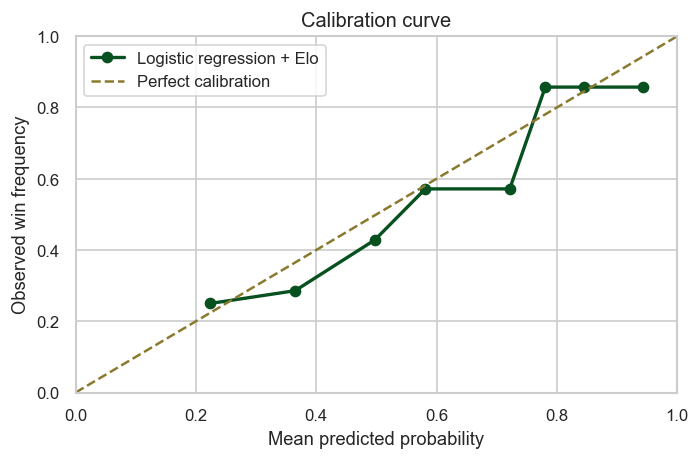

In [5]:
frac_pos, mean_pred = calibration_curve(
    y_test,
    prob_elo,
    n_bins=8,
    strategy="quantile",
)

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    mean_pred,
    frac_pos,
    marker="o",
    color=PRIMARY,
    linewidth=2,
    label="Logistic regression + Elo"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=SECONDARY,
    linewidth=1.5,
    label="Perfect calibration"
)

ax.set_title("Calibration curve")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed win frequency")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "model_calibration_curve.pdf", bbox_inches="tight")
plt.show()

### ROC Curve

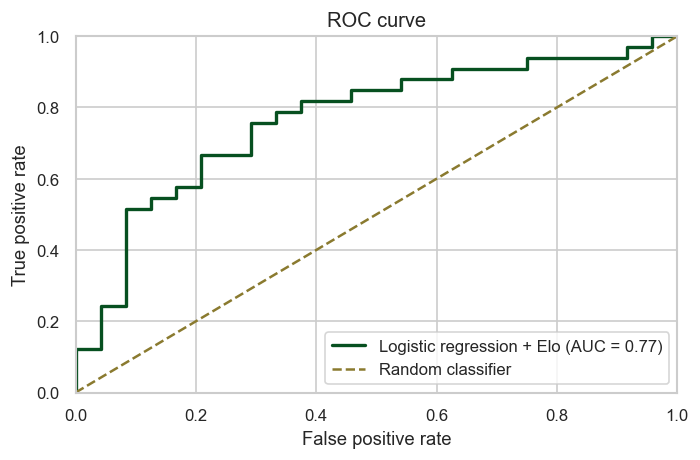

In [6]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, prob_elo)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    fpr,
    tpr,
    color=PRIMARY,
    linewidth=2,
    label=f"Logistic regression + Elo (AUC = {roc_auc:.2f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=SECONDARY,
    linewidth=1.5,
    label="Random classifier"
)

ax.set_title("ROC curve")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIG_DIR / "model_roc_curve.pdf", bbox_inches="tight")
plt.show()

## Model interpretation

In [7]:
feature_names = logreg_elo_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_elo_model.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
        "odds_ratio": np.exp(coefficients),
    })
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)

coef_df.head(15)

,feature,coefficient,odds_ratio
0,cat__tournament_1998 Tri Nations Series,1.296616,3.656900
1,cat__tournament_2009 Tri Nations Series,1.295579,3.653112
2,cat__opponent_Italy,0.915861,2.498927
3,cat__tournament_1997 South Africa rugby union ...,0.913455,2.492921
4,cat__opponent_Wales,0.886024,2.425466
5,cat__tournament_1999 Rugby World Cup,0.849041,2.337405
6,num__home,0.842026,2.321065
7,cat__opponent_Scotland,0.828333,2.289500
8,cat__tournament_2005 Tri Nations Series,0.794899,2.214216
9,cat__opponent_Argentina,0.766939,2.153165


## Save outputs

In [8]:
with open(REPORT_DIR / "model_metrics.txt", "w", encoding="utf-8") as file:
    file.write("Logistic regression model comparison\n")
    file.write("====================================\n\n")
    file.write(f"Train period: {train['date'].min()} to {train['date'].max()}\n")
    file.write(f"Test period: {test['date'].min()} to {test['date'].max()}\n\n")
    file.write(f"baseline_accuracy: {baseline_accuracy:.4f}\n\n")

    file.write("Logistic regression:\n")
    for name, value in logreg_base_metrics.items():
        file.write(f"{name}: {value:.4f}\n")

    file.write("\nLogistic regression + Elo:\n")
    for name, value in logreg_elo_metrics.items():
        file.write(f"{name}: {value:.4f}\n")

    file.write("\nClassification report: Logistic regression + Elo\n")
    file.write(classification_report(y_test, pred_elo, digits=3))

coef_df.to_csv(REPORT_DIR / "model_coefficients.csv", index=False)

logreg_comparison = pd.DataFrame([
    {"model": "Logistic regression", **logreg_base_metrics},
    {"model": "Logistic regression + Elo", **logreg_elo_metrics},
])

logreg_comparison.to_csv(REPORT_DIR / "logistic_model_comparison.csv", index=False)

print("Saved logistic regression outputs.")

Saved logistic regression outputs.
